In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

def interactive_CCM_plot(X, E=2, tau=1):
    """
    Create an interactive two-panel plot for one time series X.
    
    The top panel shows the phase space embedding of X (with embedding dimension E=2)
    using coordinates (X(t-tau), X(t)). The bottom panel shows the time series values 
    for X (starting at t=tau to align with the embedding). 
    
    When you click on a point in the phase space plot, that point is permanently marked 
    with a new color, and the corresponding point in the time series plot is marked with 
    the same color.
    
    Parameters
    ----------
    X : array-like
        Time series for variable X.
    E : int, optional
        Embedding dimension (currently supports E=2).
    tau : int, optional
        Embedding lag.
    """
    # For embedding with E=2, we lose the first 'tau' points.
    X_arr = np.array(X)
    n_points = len(X_arr) - tau  # number of embedded points
    
    # Create the embedded coordinates for X.
    # For E=2, the embedded points are: (X[t-tau], X[t]) for t=tau,...,len(X)-1.
    embedded_x = X_arr[tau:]
    embedded_y = X_arr[:n_points]
    
    # Time indices corresponding to the embedded points.
    time_axis = np.arange(tau, len(X_arr))
    # For the bottom plot, we use the values of X from t=tau onward.
    X_time = X_arr[tau:]
    
    # Set up default marker color and a color palette for selections.
    default_color = 'blue'
    color_palette = ['red', 'green', 'purple', 'orange', 'brown', 'pink', 'cyan', 'magenta']
    
    # Initialize color arrays for both plots.
    colors_phase = [default_color] * n_points
    colors_time  = [default_color] * n_points
    
    # Create a two-row subplot figure using Plotly's make_subplots.
    fig = make_subplots(rows=2, cols=1,
                        subplot_titles=["Phase Space of X (Embedding)", "Time Series of X"],
                        vertical_spacing=0.15)
    
    # Top subplot: phase space (scatter) of the embedding.
    scatter_phase = go.Scatter(
        x = embedded_y,        # x: X(t-tau)
        y = embedded_x,        # y: X(t)
        mode = 'markers',
        marker = dict(color=colors_phase, size=8),
        name = "Embedded X"
    )
    fig.add_trace(scatter_phase, row=1, col=1)
    
    # Bottom subplot: time series scatter of X (aligned with embedded indices).
    scatter_time = go.Scatter(
        x = time_axis,         # time axis corresponding to the embedded indices
        y = X_time,
        mode = 'markers',
        marker = dict(color=colors_time, size=8),
        name = "X Time Series"
    )
    fig.add_trace(scatter_time, row=2, col=1)
    
    # Convert to a FigureWidget for interactivity.
    figw = go.FigureWidget(fig)
    
    # Use a local dictionary to hold selected point indices and their assigned colors.
    selected_points = {}
    
    # Callback function: when a point in the phase space plot is clicked,
    # add it to the selection (if not already selected) with a new color.
    def update_selection(trace, points, selector):
        if points.point_inds:
            for ind in points.point_inds:
                if ind not in selected_points:
                    # Assign a new color from the palette (cycle if needed)
                    new_color = color_palette[len(selected_points) % len(color_palette)]
                    selected_points[ind] = new_color
            # Build updated color lists.
            new_colors_phase = [default_color] * n_points
            new_colors_time  = [default_color] * n_points
            for idx, col in selected_points.items():
                new_colors_phase[idx] = col
                new_colors_time[idx] = col
            with figw.batch_update():
                figw.data[0].marker.color = new_colors_phase
                figw.data[1].marker.color = new_colors_time
    
    # Attach the click event to the phase space trace (top subplot)
    figw.data[0].on_click(update_selection)
    
    figw.update_layout(height=1000, width=800, title_text="Interactive CCM Study")
    display(figw)
    return 




In [2]:
time = np.arange(100)
X = np.sin(0.1 * time) + 0.1 * np.random.randn(len(time))

interactive_CCM_plot(X, E=2, tau=10)

FigureWidget({
    'data': [{'marker': {'color': [blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue],
                        

In [3]:

import xarray as xr
import pandas as pd
import numpy as np


ds_sat = xr.open_dataset('LGMR_data/ds_sat_flipped.nc')

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre_120.csv")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


df = pd.DataFrame({
    'Time': ds_sat['age'].values,
    'X': ds_sat['sat'].isel(lat=80).isel(lon=0).values,
    'Y': df_pre['pre'].values
    
})


interactive_CCM_plot(df['X'].values, E=2, tau=10)
interactive_CCM_plot(df['Y'].values, E=2, tau=10)

FigureWidget({
    'data': [{'marker': {'color': [blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, b

FigureWidget({
    'data': [{'marker': {'color': [blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, b

In [4]:

import xarray as xr
import pandas as pd
import numpy as np


ds_sat_diff = xr.open_dataset('LGMR_data/ds_sat_diff.nc')

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


df = pd.DataFrame({
    'Time': ds_sat_diff['age'].values,
    'X': ds_sat_diff['sat_diff'].isel(lat=80).isel(lon=0).values,
    'Y': df_pre['pre'].values
    
})


interactive_CCM_plot(df['X'].values, E=2, tau=10)
interactive_CCM_plot(df['Y'].values, E=2, tau=10)

FigureWidget({
    'data': [{'marker': {'color': [blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, b

FigureWidget({
    'data': [{'marker': {'color': [blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, blue, blue,
                                   blue, blue, blue, blue, blue, blue, b

# Predict Pre using its following three data points

Random weights for the first prediction: [0.18205878 0.46212909 0.35581214]
Shape of random weights array: (116, 3)
Length of x_true: 116
Length of x_pred: 116


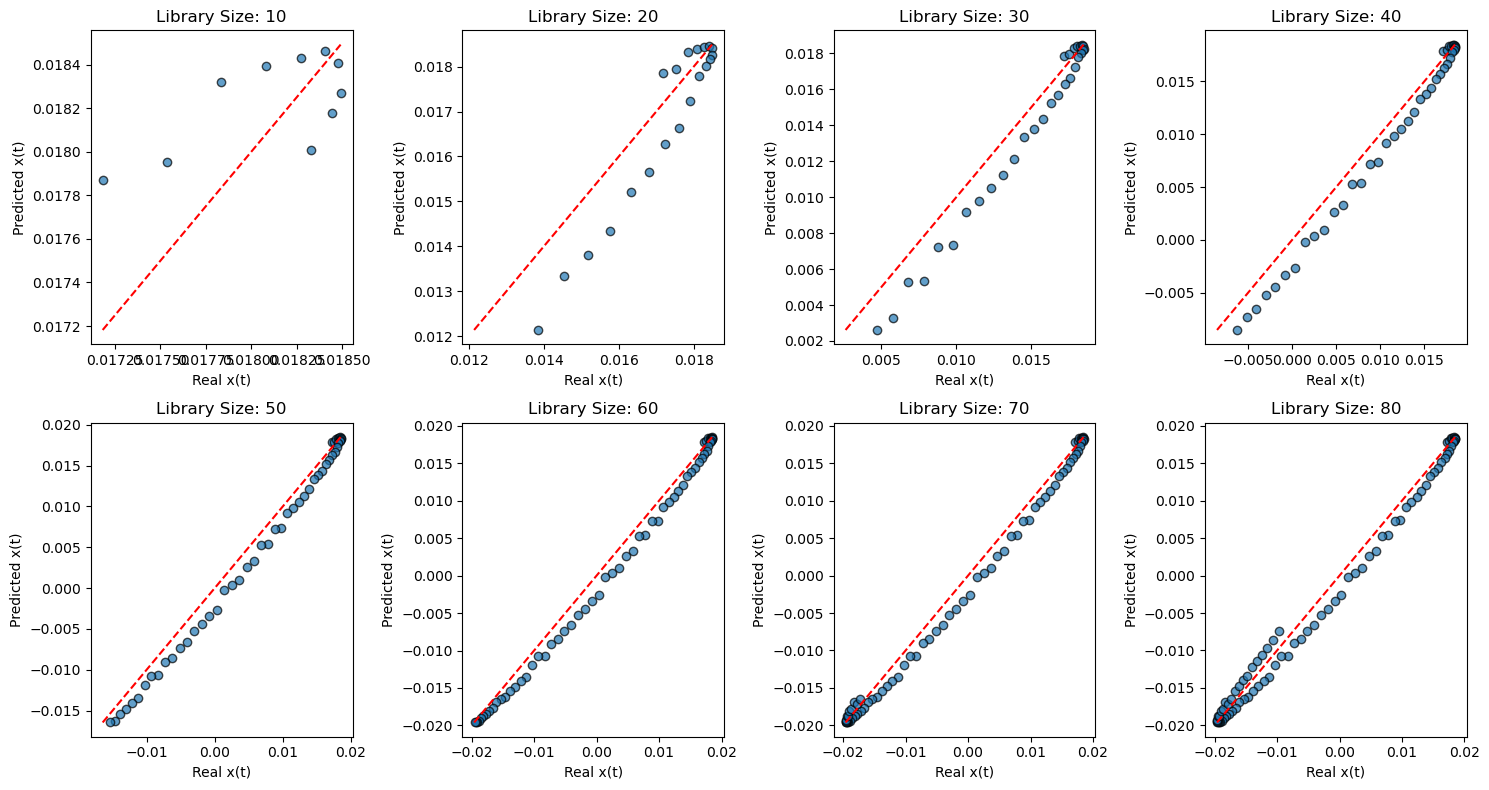

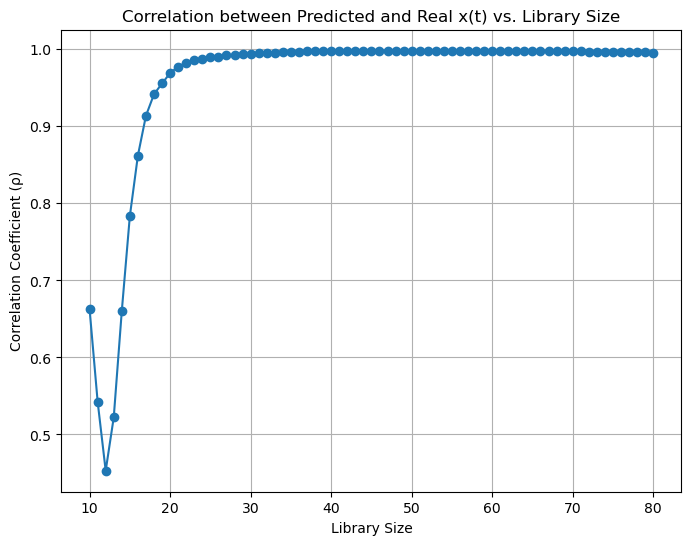

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming df_pre is already defined and contains the column 'pre'
pre = df_pre['pre'].values

# -----------------------------
# 1. Generate random weights for each prediction and compute predictions.
np.random.seed(42)  # Set seed for reproducibility.

# We can only compute predictions for t=0 to len(pre)-3.
n = len(pre) - 3

# For each prediction, generate a new set of random weights.
# This creates an array of shape (n, 3) so that each row corresponds to a specific t.
random_weights = np.random.rand(n, 3)
# Normalize each set of weights so that they sum to 1.
random_weights /= np.sum(random_weights, axis=1, keepdims=True)

# (Optional) Print the weights for the first prediction:
print("Random weights for the first prediction:", random_weights[0])
print("Shape of random weights array:", random_weights.shape)

# Compute the predicted values:
# For each time index t, use the corresponding weights to combine x(t+1), x(t+2) and x(t+3)
x_pred = (random_weights[:, 0] * pre[1:n+1] +
          random_weights[:, 1] * pre[2:n+2] +
          random_weights[:, 2] * pre[3:n+3])

# The corresponding true values are x(t) for t = 0 to n-1
x_true = pre[:n]
print("Length of x_true:", len(x_true))
print("Length of x_pred:", len(x_pred))

# -----------------------------
# 2. Experiment for different library sizes.
# Define library sizes from 10 to 80. For each, compute Pearson's correlation.
library_sizes = np.arange(10, 81)  # Library sizes: 10, 11, ..., 80.
rho_values = []  # To store correlation coefficients.

for L in library_sizes:
    # Use the first L points from the valid indices (predictions start at index 0 and go to L-1).
    if L <= len(x_true):
        r = np.corrcoef(x_true[:L], x_pred[:L])[0, 1]
        rho_values.append(r)
    else:
        break

rho_values = np.array(rho_values)
library_sizes = library_sizes[:len(rho_values)]

# -----------------------------
# 3. Plotting
# Figure 1: Subplots of scatter plots (for selected library sizes) showing x_pred vs. x_true.
selected_sizes = np.arange(10, 81, 10)  # For example: 10, 20, ..., 80.
n_selected = len(selected_sizes)
n_cols = 4
n_rows = int(np.ceil(n_selected / n_cols))
fig1, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, L in enumerate(selected_sizes):
    if L > len(x_true):
        continue
    axes[i].scatter(x_true[:L], x_pred[:L], alpha=0.7, edgecolor='k')
    axes[i].set_title(f'Library Size: {L}')
    axes[i].set_xlabel('Real x(t)')
    axes[i].set_ylabel('Predicted x(t)')
    # Plot the 1-to-1 line for reference.
    mmin = min(x_true[:L].min(), x_pred[:L].min())
    mmax = max(x_true[:L].max(), x_pred[:L].max())
    axes[i].plot([mmin, mmax], [mmin, mmax], 'r--', linewidth=1.5)

# Turn off any extra subplots.
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Figure 2: Plot the correlation (rho) as a function of library size.
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.plot(library_sizes, rho_values, marker='o', linestyle='-')
ax2.set_xlabel("Library Size")
ax2.set_ylabel("Correlation Coefficient (ρ)")
ax2.set_title("Correlation between Predicted and Real x(t) vs. Library Size")
plt.grid(True)
plt.show()


# Same, but calculate rho value using 10 randomly selected data points

Random weights for the first prediction: [0.18205878 0.46212909 0.35581214]
Shape of random weights array: (116, 3)
Length of x_true: 116
Length of x_pred: 116


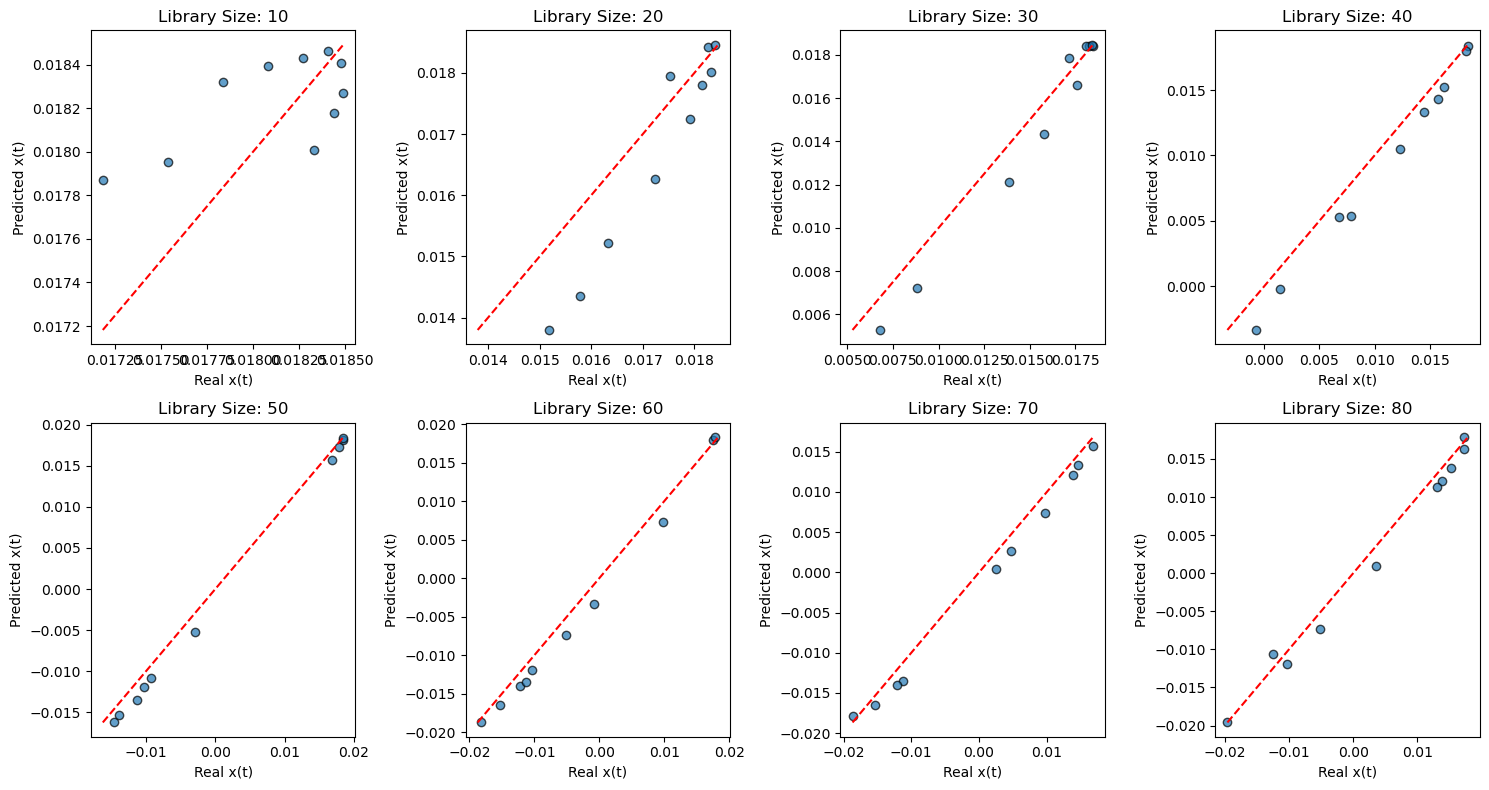

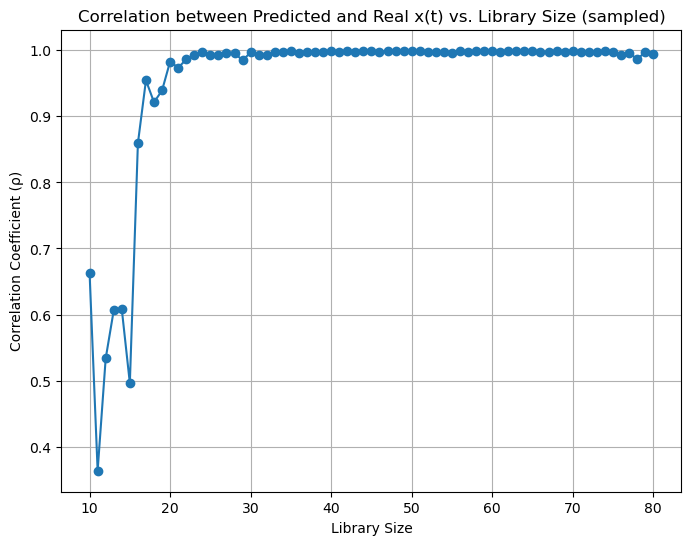

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0. Define the number of random sample points to use.
sample = 10  # Number of sample points to randomly select

# -----------------------------
# 1. Obtain the pre time series from a DataFrame column.
# (Make sure df_pre is defined and has a column named 'pre')
pre = df_pre['pre'].values

# -----------------------------
# 2. For each prediction, randomly assign weights and compute predictions.
np.random.seed(42)  # For reproducibility

# We can only compute predictions for t=0 to len(pre)-3.
n = len(pre) - 3

# Generate an array of random weights of shape (n, 3) 
# so that each time index gets its own set of weights.
random_weights = np.random.rand(n, 3)
random_weights /= np.sum(random_weights, axis=1, keepdims=True)

# (Optional) Print the weights for the first prediction:
print("Random weights for the first prediction:", random_weights[0])
print("Shape of random weights array:", random_weights.shape)

# Compute predicted values: for each time t,
# use the corresponding weights for x(t+1), x(t+2), and x(t+3)
x_pred = (random_weights[:, 0] * pre[1:n+1] +
          random_weights[:, 1] * pre[2:n+2] +
          random_weights[:, 2] * pre[3:n+3])

# The corresponding true values are x(t) for t = 0 to n-1.
x_true = pre[:n]
print("Length of x_true:", len(x_true))
print("Length of x_pred:", len(x_pred))

# -----------------------------
# 3. Experiment for different library sizes.
# Define library sizes from 10 to 80.
library_sizes = np.arange(10, 81)  # 10, 11, ..., 80.
rho_values = []  # To store correlation coefficients.

# For each library size, randomly sample 'sample' points from the first L indices
# and compute Pearson's correlation.
for L in library_sizes:
    # For library sizes L less than sample, use all available indices (but here L starts at 10).
    indices = np.random.choice(np.arange(L), size=sample, replace=False)
    r = np.corrcoef(x_true[indices], x_pred[indices])[0, 1]
    rho_values.append(r)

rho_values = np.array(rho_values)
library_sizes = library_sizes[:len(rho_values)]

# -----------------------------
# 4. Plotting
# Figure 1: Subplots of scatter plots for selected library sizes,
# showing the sampled x_pred vs. x_true.
selected_sizes = np.arange(10, 81, 10)  # e.g., 10, 20, ..., 80.
n_selected = len(selected_sizes)
n_cols = 4
n_rows = int(np.ceil(n_selected / n_cols))
fig1, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, L in enumerate(selected_sizes):
    if L > len(x_true):
        continue
    # Randomly sample 'sample' indices from the first L points.
    indices = np.random.choice(np.arange(L), size=sample, replace=False)
    axes[i].scatter(x_true[indices], x_pred[indices], alpha=0.7, edgecolor='k')
    axes[i].set_title(f'Library Size: {L}')
    axes[i].set_xlabel('Real x(t)')
    axes[i].set_ylabel('Predicted x(t)')
    # Plot the 1-to-1 line for reference.
    mmin = min(x_true[indices].min(), x_pred[indices].min())
    mmax = max(x_true[indices].max(), x_pred[indices].max())
    axes[i].plot([mmin, mmax], [mmin, mmax], 'r--', linewidth=1.5)

# Turn off extra subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Figure 2: Plot how the correlation coefficient (ρ) changes with library size.
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.plot(library_sizes, rho_values, marker='o', linestyle='-')
ax2.set_xlabel("Library Size")
ax2.set_ylabel("Correlation Coefficient (ρ)")
ax2.set_title("Correlation between Predicted and Real x(t) vs. Library Size (sampled)")
plt.grid(True)
plt.show()
